In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [2]:
results = pd.read_csv("../data/results.csv")

In [3]:
results = results[
    [
        "driverId",
        "grid",
        "points",
        "positionOrder"
    ]
]

In [4]:
results["winner"] = np.where(
    results["positionOrder"] == 1,
    1,
    0
)

In [5]:
driver_stats = (
    results.groupby("driverId")["points"]
    .mean()
    .reset_index()
)

driver_stats.columns = [
    "driverId",
    "avg_driver_points"
]

In [6]:
ml_data = results.merge(
    driver_stats,
    on="driverId",
    how="left"
)

In [7]:
X = ml_data[
    [
        "grid",
        "points",
        "avg_driver_points"
    ]
]

y = ml_data["winner"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [10]:
importance = rf_model.feature_importances_

for feature, score in zip(X.columns, importance):
    print(feature, ":", score)

grid : 0.1449510597737785
points : 0.6799670631883798
avg_driver_points : 0.17508187703784167


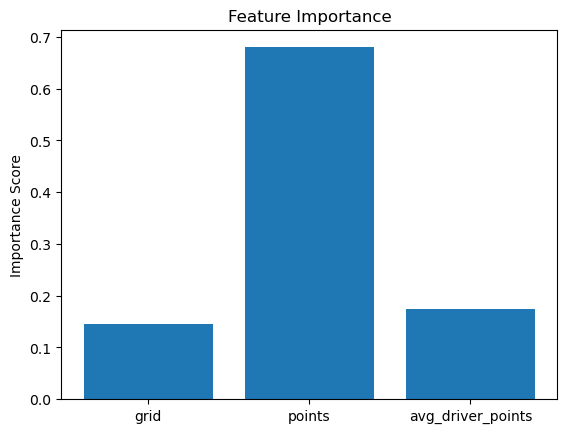

In [11]:
import matplotlib.pyplot as plt

plt.bar(
    X.columns,
    importance
)

plt.title("Feature Importance")
plt.ylabel("Importance Score")

plt.show()

# Conclusion

Random Forest feature importance was used to identify the most useful predictors.

The model ranked grid position, points, and average driver points according to their contribution.

This notebook introduced explainable machine learning and model interpretation.